# 06 — Segmentación con SAM

## ¿Qué vamos a construir hoy?

Generarás máscaras de segmentación precisas combinando YOLO (detección)
con SAM 3 (segmentación), y verás que Supervision funciona igual
sin importar qué modelo uses.

## Bounding box vs. Máscara de segmentación

**Bounding box:** un rectángulo que enmarca al objeto.
Rápido de calcular, pero incluye píxeles del fondo dentro del rectángulo.

**Máscara de segmentación:** una imagen booleana del tamaño de la imagen original.
`True` en cada píxel que pertenece al objeto, `False` en el fondo.
Resultado: la silueta exacta del objeto.

Si bounding box es recortar con tijeras rectas,
SAM es recortar siguiendo exactamente el contorno del objeto.

```
Bounding box:   ████████
                █ perro █   ← incluye fondo
                ████████

Máscara:          ██
                ██████       ← solo el objeto
                  ████
```

## La máscara como estructura de datos

Una máscara de segmentación es una **matriz NumPy booleana** del mismo tamaño
que la imagen original: un valor `True` o `False` por cada píxel.

```python
# Para una imagen de 480 × 640 px con 3 objetos detectados:
detections.mask.shape  # → (3, 480, 640)
                       #      ↑    ↑     ↑
                       #   N obj  alto  ancho
```

- `True` (o `1`) → ese píxel **pertenece al objeto**.
- `False` (o `0`) → ese píxel **es fondo**.

Operaciones directas con NumPy:
```python
mascara = detections.mask[0]       # máscara del primer objeto (shape: alto × ancho)
area    = mascara.sum()            # número de píxeles del objeto
fraccion = area / mascara.size     # qué fracción de la imagen ocupa el objeto
recorte = imagen.copy()
recorte[~mascara] = 0              # poner a negro todo lo que NO es el objeto
```

La precisión es a nivel de **píxel individual** — muy diferente al rectángulo del
bounding box que incluye fondo. Esto es clave para medir área real, eliminar el
fondo o generar datasets de entrenamiento con siluetas exactas.


In [1]:
!pip install supervision ultralytics
import supervision as sv
from ultralytics import YOLO, SAM
import cv2
import numpy as np
import matplotlib.pyplot as pyplot
import urllib.request 
from pathlib import Path

Path("assets").mkdir(exist_ok=True)
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "assets/bus.jpg")
image = cv2.imread("assets/bus.jpg")
print(f"Imagen cargada: {image.shape}")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\bruni\miniconda3\Lib\site-packages\supervision\annotators\core.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.interpolate import splev, splprep


Imagen cargada: (1080, 810, 3)


## Paso 1: Detectar objetos con YOLO

Las coordenadas de YOLO son las "pistas" que le damos a SAM
para que sepa dónde mirar en la imagen.


0: 640x480 4 persons, 1 bus, 1 stop sign, 53.0ms
Speed: 8.3ms preprocess, 53.0ms inference, 11.4ms postprocess per image at shape (1, 3, 640, 480)
YOLO detect 6


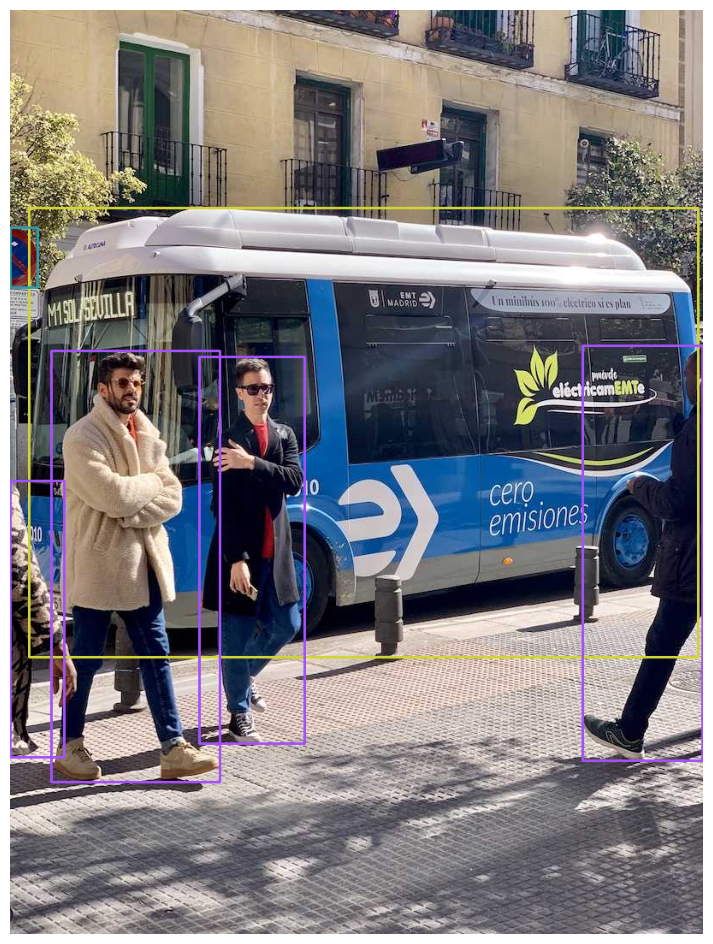

In [2]:
yolo_model = YOLO('yolov8n.pt')
yolo_results = yolo_model(image)[0]
yolo_detections = sv.Detections.from_ultralytics(yolo_results)

print(f"YOLO detect {len(yolo_detections)}")

box_annotator = sv.BoxAnnotator()
scene_yolo = box_annotator.annotate(image.copy(), detections=yolo_detections)
sv.plot_image(scene_yolo)


## Paso 2: Generar máscaras con SAM 3

SAM 3 usa las cajas de YOLO como prompts: le dicen "busca un objeto aquí"
y SAM genera la silueta exacta de ese objeto.

SAM 3 también acepta prompts de texto — lo veremos en el Experimento 4.


In [3]:
sam_model = SAM("sam3.pt")

bboxes = yolo_detections.xyxy.tolist()

sam_results = sam_model(image, bboxes=bboxes)[0]

sam_detections = sv.Detections.from_ultralytics(sam_results)

print(f"Sam detections: {len(sam_detections)}")
print(f"Tienen mascaras? {sam_detections.mask is not None}")
if sam_detections.mask is not None:
    print(f"Shape de las mascaras: {sam_detections.mask.shape}")


WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]


c:\Users\bruni\miniconda3\Lib\site-packages\ultralytics\models\sam\sam3\vitdet.py:204: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  x = F.scaled_dot_product_attention(q, k, v)


0: 1036x1036 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 793.5ms
Speed: 5.1ms preprocess, 793.5ms inference, 16.6ms postprocess per image at shape (1, 3, 1036, 1036)
Sam detections: 6
Tienen mascaras? True
Shape de las mascaras: (6, 1080, 810)


## Paso 3: Visualización Raw de Máscaras

En lugar de usar un visualizador avanzado aquí, vamos a dibujar la máscara directamente usando `matplotlib` para entenderla matemáticamente.
**Nota:** El uso avanzado de `sv.MaskAnnotator` (con opacidades, colores por clase, etc.) lo veremos a fondo en la clase 7

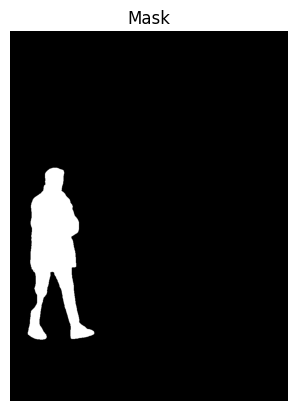

In [12]:
import matplotlib.pyplot as plt
import numpy as np

first_mask = sam_detections.mask[1]
plt.imshow(first_mask, cmap='gray')
plt.title('Mask')
plt.axis('off')
plt.show()


## Pausa y observa: ¿Qué hay dentro de una máscara?

Tipo: <class 'numpy.ndarray'>
Shape: (1080, 810)
Valores: [False  True]
Píxeles del objeto: 46648
Píxeles totales:    874800


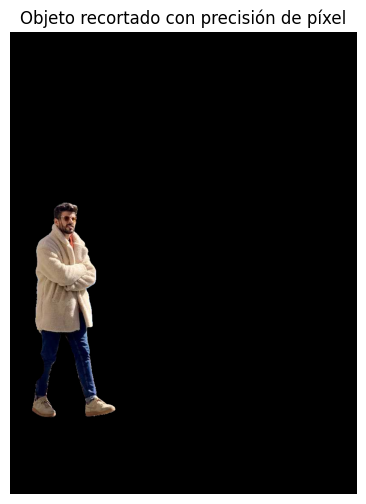

In [15]:
if sam_detections.mask is not None:
    primera_mascara = sam_detections.mask[1]  # máscara del primer objeto
    
    print(f"Tipo: {type(primera_mascara)}")
    print(f"Shape: {primera_mascara.shape}")     # (alto, ancho) — del tamaño de la imagen
    print(f"Valores: {np.unique(primera_mascara)}")  # solo True y False
    print(f"Píxeles del objeto: {primera_mascara.sum()}")
    print(f"Píxeles totales:    {primera_mascara.size}")
    
    # Recortar solo el objeto usando la máscara como "molde"
    objeto_recortado = image.copy()
    # ~ invierte la máscara: ponemos en negro todos los píxeles que NO son el objeto
    objeto_recortado[~primera_mascara] = 0
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(objeto_recortado, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Objeto recortado con precisión de píxel")
    plt.show()
else:
    ()
    #esto es yolo puro

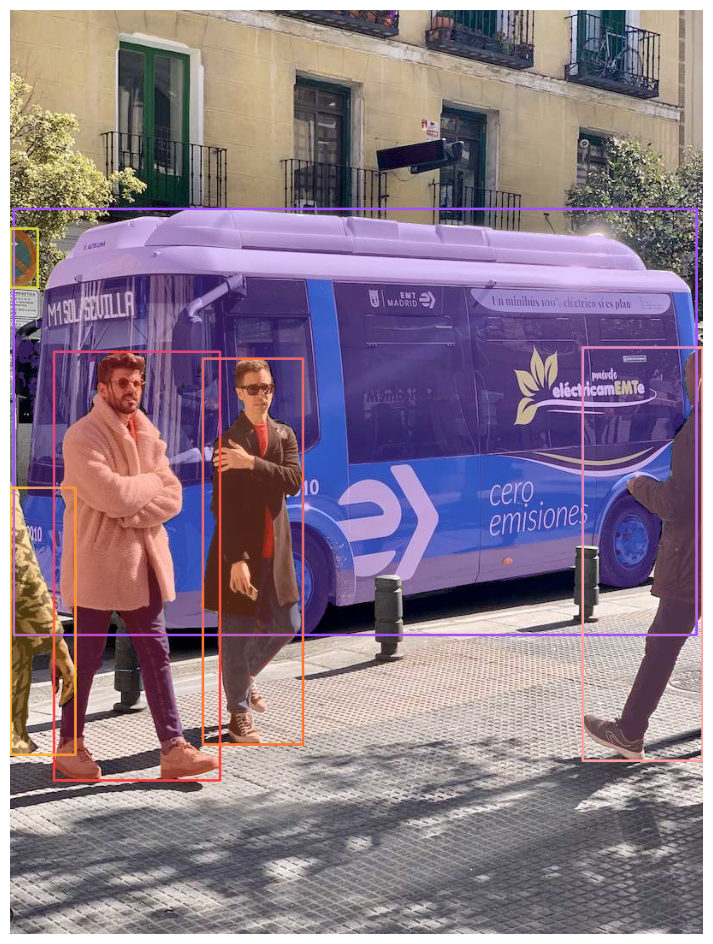

In [19]:
from ultralytics.models.sam.sam3 import sam3_image
mask_annotator = sv.MaskAnnotator(opacity = 0.3)
box_annotator = sv.BoxAnnotator()

annotated = box_annotator.annotate(image.copy(), detections=sam_detections)

if sam_detections.mask is not None:
    annotated = mask_annotator.annotate(annotated, detections=sam_detections)

sv.plot_image(annotated)


WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 757.3ms
Speed: 7.0ms preprocess, 757.3ms inference, 0.9ms postprocess per image at shape (1, 3, 1036, 1036)


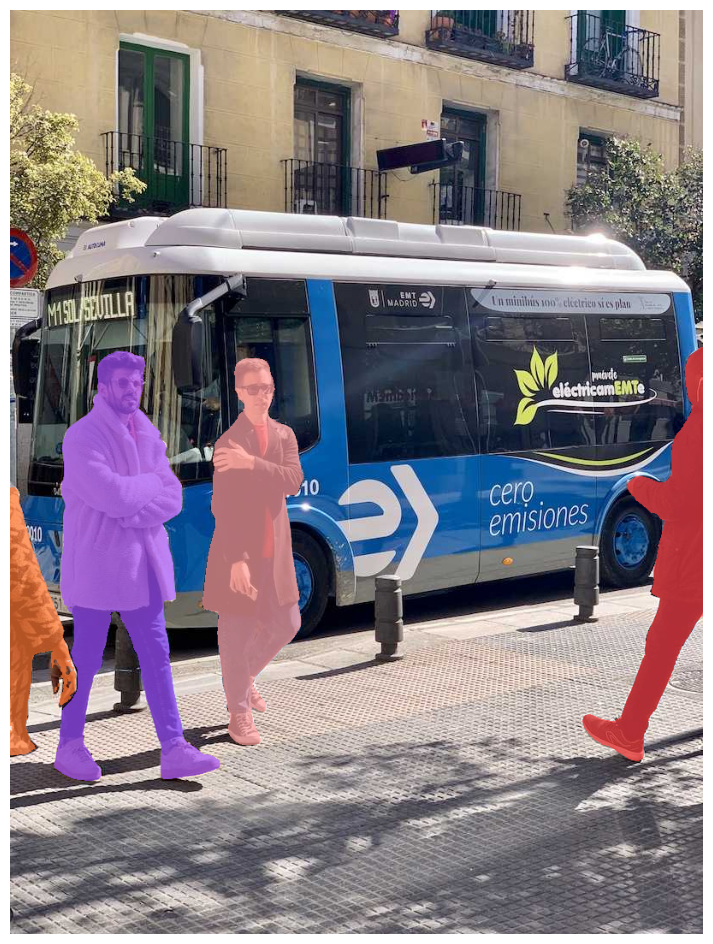

In [23]:
mask_annotator = sv.MaskAnnotator(opacity=0.7)
are_persons = yolo_detections.class_id == 0
persons_detections = yolo_detections[are_persons]
persons_bboxes = persons_detections.xyxy.tolist()
sam_results = sam_model(image, bboxes=persons_bboxes)[0]
sam_detections = sv.Detections.from_ultralytics(sam_results)

persons_scene = mask_annotator.annotate(image.copy(), detections=sam_detections)

sv.plot_image(persons_scene)